# Transport-matrix + LSTM comparison notebook

This notebook is a standalone version of the workflow. It:

1. loads the master dataset and station metadata,
2. builds a Gaussian-plume transport matrix for a selected timestamp,
3. solves the inverse problem to infer `Q` (emission rates),
4. constructs a time-series dataset,
5. trains two LSTM models:
   - **Baseline:** predict concentrations directly,
   - **Physics-informed:** predict `Q`, then reconstruct concentrations through `T @ Q`,
6. compares the two approaches on held-out timestamps.

Adjust the paths and pollutant name at the top if needed.

In [1]:
# If needed, install dependencies in your environment first:
# Cell 1

!pip install numpy pandas matplotlib scipy scikit-learn nbformat arviz pymc pytensor

from pathlib import Path
from collections import Counter
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import nnls
from scipy.linalg import lstsq, svd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)
np.set_printoptions(linewidth=140, suppress=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
# 2

# -----------------------------
# Configuration
# -----------------------------

POLLUTANT = "pm25"   # change to another gas if needed
H_STACK = 20.0       # effective stack / emission height [m]

SEQ_LEN = 24         # number of previous timesteps used by LSTM
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.15
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 8

# Paths: try to discover the project root robustly instead of assuming a fixed depth.
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for p in candidates:
        data_dir = p / "backend" / "data"
        if (data_dir / "artifacts" / "final_master_dataset.csv").exists() and (data_dir / "raw" / "stations.csv").exists():
            return p
    return start

ROOT_DIR = find_project_root()
DATA_DIR = ROOT_DIR / "backend" / "data"
MASTER_DATASET_FILE = DATA_DIR / "artifacts" / "final_master_dataset.csv"
STATIONS_FILE = DATA_DIR / "raw" / "stations.csv"

print("ROOT_DIR:", ROOT_DIR)
print("MASTER_DATASET_FILE exists:", MASTER_DATASET_FILE.exists())
print("STATIONS_FILE exists:", STATIONS_FILE.exists())

if not MASTER_DATASET_FILE.exists():
    raise FileNotFoundError(f"Missing master dataset: {MASTER_DATASET_FILE}")
if not STATIONS_FILE.exists():
    raise FileNotFoundError(f"Missing stations file: {STATIONS_FILE}")


ROOT_DIR: /home/shashank/Desktop/rvce/AirModeling
MASTER_DATASET_FILE exists: True
STATIONS_FILE exists: True


In [3]:
# 3

# -----------------------------
# Load station metadata + master dataset
# -----------------------------
stations_df = pd.read_csv(STATIONS_FILE)

# Normalize expected column names if needed
rename_map = {}
for c in stations_df.columns:
    if c.lower() == "station_name":
        rename_map[c] = "StationName"
    elif c.lower() == "latitude":
        rename_map[c] = "Latitude"
    elif c.lower() == "longitude":
        rename_map[c] = "Longitude"
stations_df = stations_df.rename(columns=rename_map)

required_cols = {"StationName", "Latitude", "Longitude"}
missing = required_cols - set(stations_df.columns)
if missing:
    raise ValueError(f"stations.csv is missing required columns: {missing}")

STATION_NAMES = stations_df["StationName"].dropna().astype(str).unique().tolist()
N = len(STATION_NAMES)

print(f"Number of stations: {N}")
display(stations_df.head())

df_full = pd.read_csv(MASTER_DATASET_FILE, parse_dates=["time"])
df_full = df_full[df_full["station_name"].isin(STATION_NAMES)].copy()

print("df_full shape:", df_full.shape)
display(df_full.head())
display(df_full.dtypes)

Number of stations: 14


,slNo,StationName,organization,Latitude,Longitude,site_id
0,1,BTMLayout,CPCB,12.9135,77.5951,162
1,2,BWSSBKadabesanahalli,CPCB,12.9352,77.6814,164
2,3,BapujiNagar,KSPCB,12.9519,77.5398,1553
3,4,CityRailwayStation,KSPCB,12.9757,77.5661,165
4,5,Hebbal,KSPCB,13.0292,77.5859,1554


df_full shape: (420480, 25)


,time,pm25,pm10,no,no2,nox,nh3,so2,co,o3,benzene,toluene,average_temperature,relative_humidity,wind_speed,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,station_name,site,org,latitude,longitude
0,2025-01-01 00:00:00,36.0000,90.0000,3.1000,11.8000,9.8000,5.0000,4.5000,500.0000,33.3000,0.3000,1.6000,20.8000,41.0000,0.0000,114.0000,0.0000,0.0000,0.0000,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
1,2025-01-01 00:15:00,36.0000,90.0000,3.2000,12.4000,10.2000,5.3000,4.6000,480.0000,35.5000,0.3000,1.7000,20.8000,41.0000,0.0000,112.0000,0.0000,0.0000,0.0000,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
2,2025-01-01 00:30:00,36.0000,90.0000,3.2000,11.3000,9.6000,5.0000,4.7000,560.0000,33.6000,0.3000,1.7000,20.8000,41.0000,0.0000,117.0000,0.0000,0.0000,0.0000,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
3,2025-01-01 00:45:00,47.0000,118.0000,2.7000,12.3000,9.7000,5.2000,4.8500,640.0000,34.2000,0.3000,1.7500,20.4000,40.0000,0.0000,112.0000,0.0000,0.0000,0.0000,726.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
4,2025-01-01 01:00:00,47.0000,118.0000,2.8000,11.2000,9.3000,5.8000,5.0000,780.0000,33.3000,0.3000,1.8000,20.4000,40.0000,0.0000,118.0000,0.0000,0.0000,0.0000,726.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398


time                   datetime64[ns]
pm25                          float64
pm10                          float64
no                            float64
no2                           float64
nox                           float64
nh3                           float64
so2                           float64
co                            float64
o3                            float64
benzene                       float64
toluene                       float64
average_temperature           float64
relative_humidity             float64
wind_speed                    float64
wind_direction                float64
rainfall                      float64
total_rainfall                float64
solar_radiation               float64
pressure                      float64
station_name                   object
site                            int64
org                            object
latitude                      float64
longitude                     float64
dtype: object

In [4]:
# 4

# -----------------------------
# Utility functions for the Gaussian plume model
# -----------------------------
station_lat = stations_df.set_index("StationName").loc[STATION_NAMES, "Latitude"].astype(float).to_numpy()
station_lon = stations_df.set_index("StationName").loc[STATION_NAMES, "Longitude"].astype(float).to_numpy()

def haversine_m(lat1, lon1, lat2, lon2):
    # Great-circle distance in meters
    R = 6371000.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return 2.0 * R * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

def bearing_deg(lat1, lon1, lat2, lon2):
    # Initial bearing from point 1 to point 2, degrees clockwise from north
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    y = np.sin(dlon) * np.cos(phi2)
    x = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlon)
    brng = np.degrees(np.arctan2(y, x))
    return (brng + 360.0) % 360.0

def angle_diff_deg(a, b):
    # Smallest absolute angular difference in degrees
    d = (a - b + 180.0) % 360.0 - 180.0
    return np.abs(d)

def stability_class(wind_speed, solar_radiation, is_day):
    # Simple Pasquill-like class heuristic
    u = float(wind_speed) if np.isfinite(wind_speed) else 0.0
    sr = float(solar_radiation) if np.isfinite(solar_radiation) else 0.0

    if is_day:
        if sr > 700:
            if u < 2:
                return "A"
            elif u < 3:
                return "B"
            elif u < 5:
                return "C"
            else:
                return "D"
        elif sr > 350:
            if u < 2:
                return "B"
            elif u < 5:
                return "C"
            else:
                return "D"
        else:
            if u < 3:
                return "C"
            else:
                return "D"
    else:
        if u < 2:
            return "F"
        elif u < 5:
            return "E"
        else:
            return "D"

# Approximate Pasquill-Gifford power-law coefficients for sigma_y and sigma_z
SIGMA_PARAMS = {
    "A": dict(ay=0.22, by=0.90, az=0.20, bz=0.80),
    "B": dict(ay=0.16, by=0.90, az=0.12, bz=0.80),
    "C": dict(ay=0.11, by=0.90, az=0.08, bz=0.75),
    "D": dict(ay=0.08, by=0.85, az=0.06, bz=0.70),
    "E": dict(ay=0.06, by=0.85, az=0.03, bz=0.65),
    "F": dict(ay=0.04, by=0.85, az=0.016, bz=0.65),
}

MIN_WIND_SPEED_MS = 0.5
MIN_DOWNWIND_DIST_M = 500.0
MAX_SIGMA_Z_M = 500.0

def sigma_yz(x_m, stability):
    x_m = max(float(x_m), MIN_DOWNWIND_DIST_M)
    p = SIGMA_PARAMS[stability]
    sigma_y = p["ay"] * (x_m ** p["by"])
    sigma_z = p["az"] * (x_m ** p["bz"])
    sigma_z = min(sigma_z, MAX_SIGMA_Z_M)
    return sigma_y, sigma_z

def transport_element(lat_src, lon_src, lat_rec, lon_rec, wind_speed, wind_dir_from, stability, H=20.0):
    # Gaussian plume contribution from source j to receptor i.
    # wind_dir_from: meteorological direction FROM which the wind blows.
    u = float(wind_speed)
    if not np.isfinite(u) or u < MIN_WIND_SPEED_MS:
        return 0.0

    d = haversine_m(lat_src, lon_src, lat_rec, lon_rec)
    if d <= 0:
        return 0.0

    brng = bearing_deg(lat_src, lon_src, lat_rec, lon_rec)
    wind_to = (float(wind_dir_from) + 180.0) % 360.0
    rel = np.radians(angle_diff_deg(brng, wind_to))

    x_down = d * np.cos(rel)
    y_cross = d * np.sin(rel)

    if x_down <= 0:
        return 0.0

    sigma_y, sigma_z = sigma_yz(x_down, stability)
    if sigma_y <= 0 or sigma_z <= 0:
        return 0.0

    coeff = 1.0 / (np.pi * u * sigma_y * sigma_z)
    plume = coeff * np.exp(-(y_cross ** 2) / (2.0 * sigma_y ** 2)) * np.exp(-(H ** 2) / (2.0 * sigma_z ** 2))
    return float(plume)

def build_transport_matrix(timestamp, wind_speed_wide, wind_dir_wide, solar_wide, station_names=STATION_NAMES, station_lat=station_lat, station_lon=station_lon, H=H_STACK):
    ws = wind_speed_wide.loc[timestamp].to_numpy(dtype=float)
    wd = wind_dir_wide.loc[timestamp].to_numpy(dtype=float)
    sr = solar_wide.loc[timestamp].to_numpy(dtype=float)

    is_day = 6 <= pd.Timestamp(timestamp).hour <= 18
    stab = [stability_class(ws[j], sr[j], is_day) for j in range(len(station_names))]

    N = len(station_names)
    T = np.zeros((N, N), dtype=float)
    for j in range(N):       # source
        for i in range(N):   # receptor
            T[i, j] = transport_element(
                station_lat[j], station_lon[j],
                station_lat[i], station_lon[i],
                ws[j], wd[j], stab[j], H=H
            )
    return T, stab, ws, wd, sr

def solve_q_nnls(C_obs, T):
    Q, _ = nnls(T, C_obs)
    return Q

In [5]:
# 5

# -----------------------------
# Helper to create wide tables (time × station)
# -----------------------------
def wide_table(df, value_col):
    wide = (
        df.pivot(index="time", columns="station_name", values=value_col)
          .sort_index()
          .reindex(columns=STATION_NAMES)
    )

    # Make sure the index is a proper DatetimeIndex for time interpolation.
    wide.index = pd.to_datetime(wide.index)

    # Convert to numeric early so any stray strings become NaN and can be repaired.
    wide = wide.apply(pd.to_numeric, errors="coerce")

    # Interpolate within each column over time, then fill any edge gaps.
    wide = wide.interpolate(method="time", limit_direction="both")
    wide = wide.ffill().bfill()

    # If a station column is still entirely missing, fall back to the column median.
    col_medians = wide.median(axis=0, skipna=True)
    wide = wide.fillna(col_medians)

    # Final fallback: if anything is still missing, set it to zero rather than carrying NaN forward.
    if wide.isna().any().any():
        wide = wide.fillna(0.0)

    return wide.astype(float)

# Wide concentration table and wide meteorology tables
pivot_C = wide_table(df_full.dropna(subset=[POLLUTANT]), POLLUTANT)
wind_speed_wide = wide_table(df_full.dropna(subset=["wind_speed"]), "wind_speed")
wind_dir_wide = wide_table(df_full.dropna(subset=["wind_direction"]), "wind_direction")
solar_wide = wide_table(df_full.dropna(subset=["solar_radiation"]), "solar_radiation")
temp_wide = wide_table(df_full.dropna(subset=["average_temperature"]), "average_temperature")
rh_wide = wide_table(df_full.dropna(subset=["relative_humidity"]), "relative_humidity")

# Align all tables
common_times = pivot_C.index.intersection(wind_speed_wide.index).intersection(wind_dir_wide.index).intersection(solar_wide.index)
pivot_C = pivot_C.loc[common_times]
wind_speed_wide = wind_speed_wide.loc[common_times]
wind_dir_wide = wind_dir_wide.loc[common_times]
solar_wide = solar_wide.loc[common_times]
temp_wide = temp_wide.loc[common_times]
rh_wide = rh_wide.loc[common_times]

print("Aligned time steps:", len(common_times))
display(pivot_C.head())


Aligned time steps: 35040


station_name,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,0.0000,0.0000,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,1.0500,0.0000,29.0000,57.0000
2025-01-01 00:15:00,0.0000,0.0000,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,1.0500,0.0000,29.0000,57.0000
2025-01-01 00:30:00,0.0000,0.0000,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,0.9900,0.0000,29.0000,57.0000
2025-01-01 00:45:00,0.0000,0.0000,47.0000,0.0000,87.0000,64.4000,92.0000,87.4300,33.0100,48.2100,0.9600,0.0000,29.0000,68.0000
2025-01-01 01:00:00,0.0000,0.0000,47.0000,0.0000,87.0000,67.8000,92.0000,89.0100,33.1000,48.7900,0.9600,0.0000,28.8900,68.0000


In [6]:
# 6

# -----------------------------
# Choose one representative timestamp and analyze it
# -----------------------------
# Use a timestamp where all 14 station values are available if possible.
# If not, fall back to the best-covered timestamp and fill missing values.

pm25_wide = pivot_C.reindex(columns=STATION_NAMES)

complete_times = pm25_wide.dropna().index

if len(complete_times) > 0:
    snapshot_time = complete_times[0]
    print("Using fully complete snapshot time:", snapshot_time)
else:
    coverage = pm25_wide.notna().sum(axis=1)
    snapshot_time = coverage.idxmax()
    print("No fully complete timestamp found.")
    print("Using best-covered snapshot time:", snapshot_time)
    print("Stations available:", int(coverage.max()), "out of", len(STATION_NAMES))

# Build the concentration vector for the chosen time
snapshot_series = pm25_wide.loc[snapshot_time].astype(float)

missing_stations = snapshot_series[snapshot_series.isna()].index.tolist()
if missing_stations:
    print("Missing stations in snapshot:", missing_stations)
    # fill only for the single-snapshot inverse demo
    snapshot_series = snapshot_series.fillna(snapshot_series.median())

T_matrix, stab_snapshot, WS_snapshot, WD_snapshot, SR_snapshot = build_transport_matrix(
    snapshot_time, wind_speed_wide, wind_dir_wide, solar_wide
)

C_obs = snapshot_series.to_numpy(dtype=float)

print("T_matrix shape:", T_matrix.shape)
print("C_obs shape:", C_obs.shape)
print("Any NaN in C_obs?", np.isnan(C_obs).any())
print("Any NaN in T_matrix?", np.isnan(T_matrix).any())

Using fully complete snapshot time: 2025-01-01 00:00:00
T_matrix shape: (14, 14)
C_obs shape: (14,)
Any NaN in C_obs? False
Any NaN in T_matrix? False


In [7]:
print("T_matrix NaNs:", np.isnan(T_matrix).sum())
print("T_matrix Infs:", np.isinf(T_matrix).sum())

print("C_obs NaNs:", np.isnan(C_obs).sum())
print("C_obs Infs:", np.isinf(C_obs).sum())

T_matrix NaNs: 0
T_matrix Infs: 0
C_obs NaNs: 0
C_obs Infs: 0


In [8]:
for station, value in zip(STATION_NAMES, C_obs):
    print(station, value)

BTMLayout 0.0
BWSSBKadabesanahalli 0.0
BapujiNagar 36.0
CityRailwayStation 0.0
Hebbal 62.0
HombegowdaNagar 61.0
Jayanagar5thBlock 65.0
Jigani 71.16
KasturiNagar 32.99
Peenya 47.92
RvceMailasandra 1.05
SaneguravaHalli 0.0
ShivapuraPeenya 29.0
SilkBoard 57.0


In [9]:
# 7

# -----------------------------
# Classical inverse solvers on the snapshot
# -----------------------------
Q_lstsq, res_lstsq, rank_lstsq, s_lstsq = lstsq(T_matrix, C_obs)
Q_nnls = solve_q_nnls(C_obs, T_matrix)

def tikhonov(T, C, lam=0.1):
    n = T.shape[1]
    A = T.T @ T + lam * np.eye(n)
    b = T.T @ C
    return np.linalg.solve(A, b)

def truncated_svd_solve(T, C, thresh_ratio=1e-3):
    U, s, Vt = svd(T, full_matrices=False)
    thresh = thresh_ratio * s[0]
    s_inv = np.where(s > thresh, 1.0 / s, 0.0)
    return Vt.T @ (s_inv * (U.T @ C))

Q_tikh = tikhonov(T_matrix, C_obs, lam=0.1)
Q_svd = truncated_svd_solve(T_matrix, C_obs, thresh_ratio=1e-3)

methods = ["lstsq", "NNLS", "Tikhonov", "TruncSVD"]
Q_all = [Q_lstsq, Q_nnls, Q_tikh, Q_svd]

df_Q_snapshot = pd.DataFrame({m: Q for m, Q in zip(methods, Q_all)}, index=STATION_NAMES)
df_Q_snapshot["C_obs"] = C_obs
for m, Q in zip(methods, Q_all):
    df_Q_snapshot[f"C_{m}"] = T_matrix @ Q

display(df_Q_snapshot)

print("Residual norms on snapshot:")
for m, Q in zip(methods, Q_all):
    print(f"{m:10s}: {np.linalg.norm(C_obs - T_matrix @ Q):.4f}")

/tmp/ipykernel_279805/2550329127.py:18: RuntimeWarning: divide by zero encountered in divide
  s_inv = np.where(s > thresh, 1.0 / s, 0.0)


,lstsq,NNLS,Tikhonov,TruncSVD,C_obs,C_lstsq,C_NNLS,C_Tikhonov,C_TruncSVD
BTMLayout,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BWSSBKadabesanahalli,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
BapujiNagar,0.0000,0.0000,0.0000,0.0000,36.0000,0.0000,0.0000,0.0000,0.0000
CityRailwayStation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Hebbal,0.0000,0.0000,0.0000,0.0000,62.0000,0.0000,0.0000,0.0000,0.0000
HombegowdaNagar,0.0000,0.0000,0.0000,0.0000,61.0000,61.0000,61.0000,0.0000,0.0000
Jayanagar5thBlock,0.0000,0.0000,0.0000,0.0000,65.0000,65.0000,65.0000,0.0000,65.0000
Jigani,0.0000,0.0000,0.0000,0.0000,71.1600,0.0000,0.0000,0.0000,0.0000
KasturiNagar,17186816.1756,17186816.1756,0.0025,17186816.1756,32.9900,0.0000,0.0000,0.0000,0.0000
Peenya,0.0000,0.0000,0.0000,0.0000,47.9200,0.0000,0.0000,0.0000,0.0000


Residual norms on snapshot:
lstsq     : 132.9643
NNLS      : 132.9643
Tikhonov  : 160.0797
TruncSVD  : 146.2891


In [10]:
# -----------------------------
# Build Q labels for every timestamp
# -----------------------------
# Use NNLS-derived Q as the latent target for the LSTM comparison.
# This version is more forgiving than the original cell and avoids
# discarding every timestamp because of a tiny numerical issue.

Q_rows = []
valid_times = []

n_bad_c = 0
n_bad_t = 0
n_bad_q = 0
n_failed = 0

for t in common_times:
    C_t = pivot_C.loc[t].to_numpy(dtype=float)

    # Safety: if anything slipped through, repair it instead of dropping the sample.
    if not np.all(np.isfinite(C_t)):
        s = pd.Series(C_t)
        C_t = s.interpolate(limit_direction="both").bfill().ffill().to_numpy(dtype=float)
        if not np.all(np.isfinite(C_t)):
            n_bad_c += 1
            continue

    T_t, _, _, _, _ = build_transport_matrix(t, wind_speed_wide, wind_dir_wide, solar_wide)

    # Safety fallback for tiny numerical issues in T
    if not np.all(np.isfinite(T_t)):
        T_t = np.nan_to_num(T_t, nan=0.0, posinf=0.0, neginf=0.0)

    if not np.any(T_t):
        n_bad_t += 1
        continue

    try:
        Q_t = solve_q_nnls(C_t, T_t)
        Q_t = np.asarray(Q_t, dtype=float)

        if not np.all(np.isfinite(Q_t)):
            Q_t = np.nan_to_num(Q_t, nan=0.0, posinf=0.0, neginf=0.0)

        # Zero is a valid NNLS result, so keep it.
        Q_rows.append(Q_t)
        valid_times.append(t)

    except Exception as e:
        n_failed += 1
        print(f"Failed at {t}: {e}")
        continue

if len(valid_times) == 0:
    raise ValueError("No usable timestamps were found for Q estimation.")

Q_df = pd.DataFrame(Q_rows, index=pd.DatetimeIndex(valid_times), columns=STATION_NAMES)

pivot_C = pivot_C.loc[valid_times]
wind_speed_wide = wind_speed_wide.loc[valid_times]
wind_dir_wide = wind_dir_wide.loc[valid_times]
solar_wide = solar_wide.loc[valid_times]
temp_wide = temp_wide.loc[valid_times]
rh_wide = rh_wide.loc[valid_times]

print("Usable time steps for the LSTM study:", len(valid_times))
print("Skipped for bad C:", n_bad_c)
print("Skipped for bad T:", n_bad_t)
print("Failed solver calls:", n_failed)
display(Q_df.head())


Usable time steps for the LSTM study: 34452
Skipped for bad C: 0
Skipped for bad T: 588
Failed solver calls: 0


,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
2025-01-01 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,17186816.1756,0.0000,98562595264.3313,0.0000,0.0000,0.0000
2025-01-01 00:15:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6684739525070.3447,0.0000,7464770.4447,0.0000,0.0000,0.0000
2025-01-01 00:30:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6543903104.0395,0.0000,0.0000,0.0000,0.0000,0.0000
2025-01-01 00:45:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,62386650.1304,0.0000,2339907.2615,0.0000,0.0000,0.0000
2025-01-01 01:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,589722584.6852,0.0000,1101671.5977,0.0000,0.0000,0.0000


In [11]:
# -----------------------------
# Create LSTM feature matrix
# -----------------------------
# Baseline inputs: past concentrations + aggregate meteorology
meteo_df = pd.DataFrame(
    {
        "wind_speed_mean": wind_speed_wide.mean(axis=1),
        "wind_direction_mean": wind_dir_wide.mean(axis=1),
        "solar_radiation_mean": solar_wide.mean(axis=1),
        "temperature_mean": temp_wide.mean(axis=1),
        "humidity_mean": rh_wide.mean(axis=1),
    },
    index=pivot_C.index,
)

X_full = pd.concat([pivot_C, meteo_df], axis=1)

print("X_full shape:", X_full.shape)
print("Y_C shape   :", pivot_C.shape)
print("Y_Q shape   :", Q_df.shape)

display(X_full.head())

X_full shape: (34452, 19)
Y_C shape   : (34452, 14)
Y_Q shape   : (34452, 14)


,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard,wind_speed_mean,wind_direction_mean,solar_radiation_mean,temperature_mean,humidity_mean
time,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,0.0000,0.0000,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,1.0500,0.0000,29.0000,57.0000,0.7978,84.2136,1.7336,14.4696,53.8471
2025-01-01 00:15:00,0.0000,0.0000,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,1.0500,0.0000,29.0000,57.0000,0.8878,81.4614,1.7279,14.4418,54.2350
2025-01-01 00:30:00,0.0000,0.0000,36.0000,0.0000,62.0000,61.0000,65.0000,71.1600,32.9900,47.9200,0.9900,0.0000,29.0000,57.0000,0.8135,86.8000,1.7757,14.3954,54.5014
2025-01-01 00:45:00,0.0000,0.0000,47.0000,0.0000,87.0000,64.4000,92.0000,87.4300,33.0100,48.2100,0.9600,0.0000,29.0000,68.0000,0.8378,80.5171,1.9393,14.2125,54.6521
2025-01-01 01:00:00,0.0000,0.0000,47.0000,0.0000,87.0000,67.8000,92.0000,89.0100,33.1000,48.7900,0.9600,0.0000,28.8900,68.0000,0.7928,82.6536,1.7986,14.1486,55.1066


In [12]:
# -----------------------------
# Train/test sequence builder
# -----------------------------
def build_sequences(X, Y, times, seq_len):
    X_seq, Y_seq, T_seq = [], [], []
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    times = pd.DatetimeIndex(times)

    for i in range(seq_len, len(times)):
        x_win = X[i-seq_len:i]
        y_t = Y[i]

        # keep only fully finite windows
        if np.isfinite(x_win).all() and np.isfinite(y_t).all():
            X_seq.append(x_win)
            Y_seq.append(y_t)
            T_seq.append(times[i])

    return np.asarray(X_seq), np.asarray(Y_seq), pd.DatetimeIndex(T_seq)

def time_split(X, Y, T, train_ratio=0.70, val_ratio=0.15):
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    return (
        X[:train_end], Y[:train_end], T[:train_end],
        X[train_end:val_end], Y[train_end:val_end], T[train_end:val_end],
        X[val_end:], Y[val_end:], T[val_end:]
    )

def clean_numeric_frame(df):
    out = df.copy().sort_index()
    out = out.apply(pd.to_numeric, errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.interpolate(method="time", limit_direction="both")
    out = out.ffill().bfill()

    col_medians = out.median(axis=0, skipna=True)
    out = out.fillna(col_medians)
    if out.isna().any().any():
        out = out.fillna(0.0)

    return out.astype(float)

def fit_3d_scaler(X_train):
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
    return scaler

def transform_3d(X, scaler):
    n, s, f = X.shape
    X_scaled = scaler.transform(X.reshape(-1, f))
    return X_scaled.reshape(n, s, f)

# -----------------------------
# Align and clean raw tables first
# -----------------------------
X_df = clean_numeric_frame(X_full)
C_df = clean_numeric_frame(pivot_C)
Q_df_clean = clean_numeric_frame(Q_df)

# Use common timestamps only
common_times = X_df.index.intersection(C_df.index).intersection(Q_df_clean.index)

X_df = X_df.loc[common_times]
C_df = C_df.loc[common_times]
Q_df_clean = Q_df_clean.loc[common_times]

# Final safety checks
assert np.isfinite(X_df.to_numpy()).all(), "X_df still contains NaN/Inf"
assert np.isfinite(C_df.to_numpy()).all(), "C_df still contains NaN/Inf"
assert np.isfinite(Q_df_clean.to_numpy()).all(), "Q_df_clean still contains NaN/Inf"
assert len(common_times) > SEQ_LEN + 10, "Not enough usable timestamps after cleaning."

# -----------------------------
# Build sequences on cleaned arrays
# -----------------------------
X_arr = X_df.to_numpy(dtype=float)
C_arr = C_df.to_numpy(dtype=float)
Q_arr = Q_df_clean.to_numpy(dtype=float)
times = X_df.index

X_C, Y_C, T_seq = build_sequences(X_arr, C_arr, times, SEQ_LEN)
X_Q, Y_Q, T_seq2 = build_sequences(X_arr, Q_arr, times, SEQ_LEN)

assert len(X_C) > 0, "No usable concentration sequences after cleaning."
assert len(X_Q) > 0, "No usable Q sequences after cleaning."
assert (T_seq == T_seq2).all(), "Target timestamps must align between C and Q datasets."

# -----------------------------
# Split by time
# -----------------------------
X_C_tr, Y_C_tr, T_tr, X_C_val, Y_C_val, T_val, X_C_te, Y_C_te, T_te = time_split(X_C, Y_C, T_seq)
X_Q_tr, Y_Q_tr, Tq_tr, X_Q_val, Y_Q_val, Tq_val, X_Q_te, Y_Q_te, Tq_te = time_split(X_Q, Y_Q, T_seq)

# -----------------------------
# Fit scalers using training data only
# -----------------------------
X_scaler = fit_3d_scaler(X_C_tr)
c_scaler = StandardScaler().fit(Y_C_tr)
q_scaler = StandardScaler().fit(Y_Q_tr)

# Scale all splits
X_C_tr = transform_3d(X_C_tr, X_scaler)
X_C_val = transform_3d(X_C_val, X_scaler)
X_C_te = transform_3d(X_C_te, X_scaler)

X_Q_tr = transform_3d(X_Q_tr, X_scaler)
X_Q_val = transform_3d(X_Q_val, X_scaler)
X_Q_te = transform_3d(X_Q_te, X_scaler)

Y_C_tr = c_scaler.transform(Y_C_tr)
Y_C_val = c_scaler.transform(Y_C_val)
Y_C_te = c_scaler.transform(Y_C_te)

Y_Q_tr = q_scaler.transform(Y_Q_tr)
Y_Q_val = q_scaler.transform(Y_Q_val)
Y_Q_te = q_scaler.transform(Y_Q_te)

print("Direct model sequence shapes:", X_C.shape, Y_C.shape)
print("Q model sequence shapes     :", X_Q.shape, Y_Q.shape)
print("Train/Val/Test sizes:", len(X_C_tr), len(X_C_val), len(X_C_te))

print("Any NaN in X_C?", np.isnan(X_C).any())
print("Any NaN in Y_C?", np.isnan(Y_C).any())
print("Any NaN in X_Q?", np.isnan(X_Q).any())
print("Any NaN in Y_Q?", np.isnan(Y_Q).any())
print("Scaling complete: X_scaler, c_scaler, and q_scaler are ready.")


Direct model sequence shapes: (34428, 24, 19) (34428, 14)
Q model sequence shapes     : (34428, 24, 19) (34428, 14)
Train/Val/Test sizes: 24099 5164 5165
Any NaN in X_C? False
Any NaN in Y_C? False
Any NaN in X_Q? False
Any NaN in Y_Q? False
Scaling complete: X_scaler, c_scaler, and q_scaler are ready.


In [13]:
# -----------------------------
# PyTorch dataset + LSTM regressor
# -----------------------------
class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

def make_loaders(X_tr, Y_tr, X_val, Y_val, X_te, Y_te, batch_size=BATCH_SIZE):
    train_loader = DataLoader(SeqDataset(X_tr, Y_tr), batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(SeqDataset(X_val, Y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(SeqDataset(X_te, Y_te), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

def train_lstm(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        tr = float(np.mean(train_losses))
        va = float(np.mean(val_losses))
        history["train_loss"].append(tr)
        history["val_loss"].append(va)

        print(f"Epoch {epoch:03d} | train {tr:.5f} | val {va:.5f}")

        if va < best_val - 1e-6:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

def predict(model, loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            pred = model(xb).detach().cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

In [14]:
# -----------------------------
# Train the direct concentration model
# -----------------------------
train_loader_C, val_loader_C, test_loader_C = make_loaders(
    X_C_tr, Y_C_tr, X_C_val, Y_C_val, X_C_te, Y_C_te
)

model_C = LSTMRegressor(
    input_dim=X_C.shape[-1],
    hidden_dim=HIDDEN_DIM,
    output_dim=Y_C.shape[-1],
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)

model_C, hist_C = train_lstm(model_C, train_loader_C, val_loader_C)

pred_C_scaled, true_C_scaled = predict(model_C, test_loader_C)
pred_C = c_scaler.inverse_transform(pred_C_scaled)
true_C = c_scaler.inverse_transform(true_C_scaled)

print("Direct model metrics:")
print("MAE :", mean_absolute_error(true_C.flatten(), pred_C.flatten()))
print("RMSE:", np.sqrt(mean_squared_error(true_C.flatten(), pred_C.flatten())))
print("R2  :", r2_score(true_C.flatten(), pred_C.flatten()))

Epoch 001 | train 0.44588 | val 0.33988
Epoch 002 | train 0.28172 | val 0.18654
Epoch 003 | train 0.19094 | val 0.12614
Epoch 004 | train 0.14123 | val 0.09478
Epoch 005 | train 0.11597 | val 0.09070
Epoch 006 | train 0.10548 | val 0.06932
Epoch 007 | train 0.09578 | val 0.07235
Epoch 008 | train 0.09270 | val 0.06444
Epoch 009 | train 0.08816 | val 0.10085
Epoch 010 | train 0.08499 | val 0.05653
Epoch 011 | train 0.07914 | val 0.05833
Epoch 012 | train 0.07853 | val 0.08758
Epoch 013 | train 0.07574 | val 0.06912
Epoch 014 | train 0.07608 | val 0.07611
Epoch 015 | train 0.07393 | val 0.06267
Epoch 016 | train 0.07366 | val 0.05795
Epoch 017 | train 0.06953 | val 0.06014
Epoch 018 | train 0.07061 | val 0.06359
Early stopping.
Direct model metrics:
MAE : 4.808952808380127
RMSE: 14.669929546038802
R2  : 0.8988462090492249


In [15]:
# -----------------------------
# Train the Q model
# -----------------------------
train_loader_Q, val_loader_Q, test_loader_Q = make_loaders(
    X_Q_tr, Y_Q_tr, X_Q_val, Y_Q_val, X_Q_te, Y_Q_te
)

model_Q = LSTMRegressor(
    input_dim=X_Q.shape[-1],
    hidden_dim=HIDDEN_DIM,
    output_dim=Y_Q.shape[-1],
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)

model_Q, hist_Q = train_lstm(model_Q, train_loader_Q, val_loader_Q)

pred_Q_scaled, true_Q_scaled = predict(model_Q, test_loader_Q)
pred_Q = q_scaler.inverse_transform(pred_Q_scaled)
true_Q = q_scaler.inverse_transform(true_Q_scaled)

print("Q model metrics in Q-space:")
print("MAE :", mean_absolute_error(true_Q.flatten(), pred_Q.flatten()))
print("RMSE:", np.sqrt(mean_squared_error(true_Q.flatten(), pred_Q.flatten())))
print("R2  :", r2_score(true_Q.flatten(), pred_Q.flatten()))

Epoch 001 | train 0.49925 | val 0.02520
Epoch 002 | train 0.49860 | val 0.02524
Epoch 003 | train 0.49817 | val 0.02528
Epoch 004 | train 0.49767 | val 0.02538
Epoch 005 | train 0.49676 | val 0.02526
Epoch 006 | train 0.49781 | val 0.02523
Epoch 007 | train 0.49658 | val 0.02521
Epoch 008 | train 0.49747 | val 0.02531
Epoch 009 | train 0.49603 | val 0.02633
Early stopping.
Q model metrics in Q-space:
MAE : 142818836217856.0
RMSE: 5997570367897598.0
R2  : 0.001020193099975586


In [16]:
# -----------------------------
# Reconstruct concentrations from predicted Q
# -----------------------------
# Each test target timestamp corresponds to one T(t) matrix.
C_reconstructed = []

for t, q_hat in zip(Tq_te, pred_Q):
    T_t, _, _, _, _ = build_transport_matrix(t, wind_speed_wide, wind_dir_wide, solar_wide)
    C_hat = T_t @ q_hat
    C_reconstructed.append(C_hat)

C_reconstructed = np.asarray(C_reconstructed)

print("Physics-informed reconstruction metrics:")
print("MAE :", mean_absolute_error(true_C.flatten(), C_reconstructed.flatten()))
print("RMSE:", np.sqrt(mean_squared_error(true_C.flatten(), C_reconstructed.flatten())))
print("R2  :", r2_score(true_C.flatten(), C_reconstructed.flatten()))

Physics-informed reconstruction metrics:
MAE : 33119681.911243763
RMSE: 254391669.76749364
R2  : -30418077816295.758


,Direct_LSTM_MAE,Direct_LSTM_RMSE,Direct_LSTM_R2,Q_LSTM_Recon_MAE,Q_LSTM_Recon_RMSE,Q_LSTM_Recon_R2
0,4.8090,14.6699,0.8988,33119681.9112,254391669.7675,-30418077816295.7578


,station,direct_mae,q_recon_mae
0,BTMLayout,0.0148,13442668.9265
1,BWSSBKadabesanahalli,0.0208,4906764.6197
2,BapujiNagar,9.0660,27571997.6728
3,CityRailwayStation,0.0207,23970292.0833
4,Hebbal,6.4738,32460656.7087
5,HombegowdaNagar,3.0316,11818460.3388
6,Jayanagar5thBlock,5.9229,14720229.4151
7,Jigani,11.5328,704626.7587
8,KasturiNagar,8.2550,4122786.5960
9,Peenya,5.0646,154208502.7276


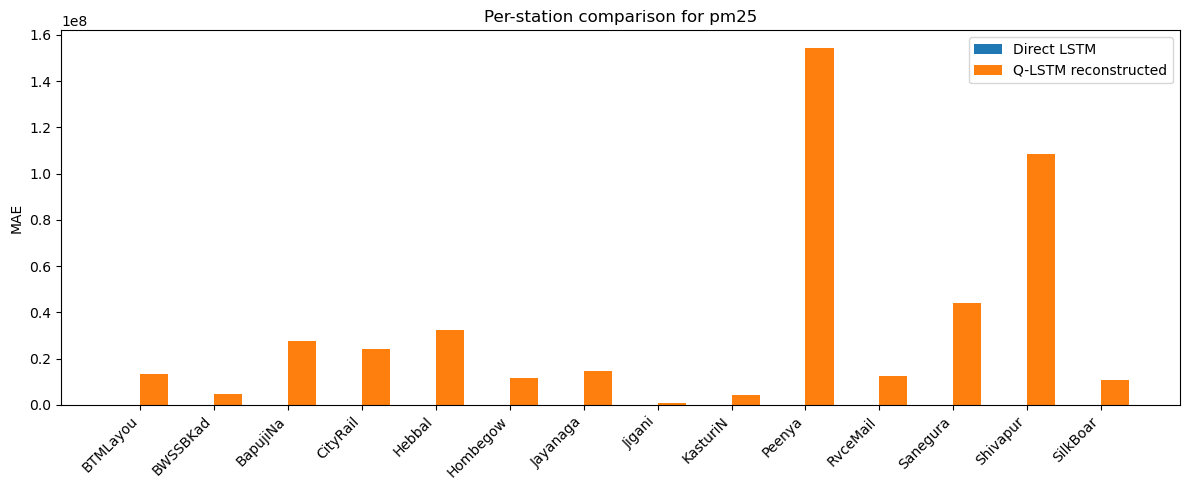

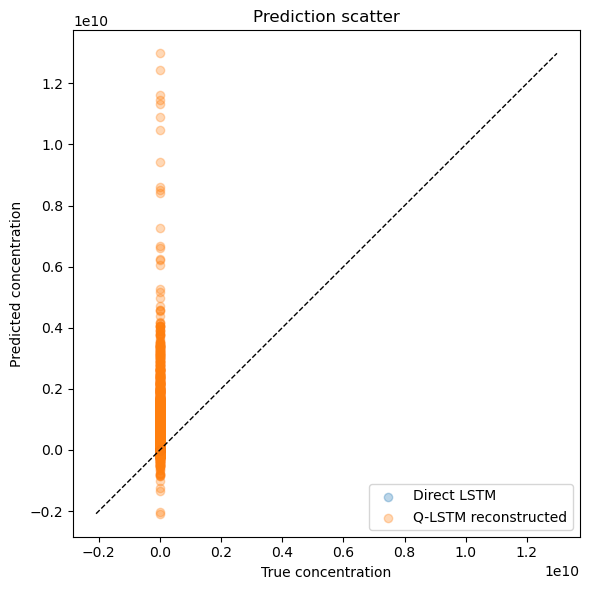

In [17]:
# -----------------------------
# Compare the two approaches
# -----------------------------
summary = pd.DataFrame(
    {
        "Direct_LSTM_MAE": [mean_absolute_error(true_C.flatten(), pred_C.flatten())],
        "Direct_LSTM_RMSE": [np.sqrt(mean_squared_error(true_C.flatten(), pred_C.flatten()))],
        "Direct_LSTM_R2": [r2_score(true_C.flatten(), pred_C.flatten())],
        "Q_LSTM_Recon_MAE": [mean_absolute_error(true_C.flatten(), C_reconstructed.flatten())],
        "Q_LSTM_Recon_RMSE": [np.sqrt(mean_squared_error(true_C.flatten(), C_reconstructed.flatten()))],
        "Q_LSTM_Recon_R2": [r2_score(true_C.flatten(), C_reconstructed.flatten())],
    }
)
display(summary)

# Per-station average absolute error
per_station_direct = np.mean(np.abs(true_C - pred_C), axis=0)
per_station_q = np.mean(np.abs(true_C - C_reconstructed), axis=0)

comparison = pd.DataFrame(
    {
        "station": STATION_NAMES,
        "direct_mae": per_station_direct,
        "q_recon_mae": per_station_q,
    }
)
display(comparison)

plt.figure(figsize=(12, 5))
x = np.arange(N)
w = 0.38
plt.bar(x - w/2, per_station_direct, width=w, label="Direct LSTM")
plt.bar(x + w/2, per_station_q, width=w, label="Q-LSTM reconstructed")
plt.xticks(x, [s[:8] for s in STATION_NAMES], rotation=45, ha="right")
plt.ylabel("MAE")
plt.title(f"Per-station comparison for {POLLUTANT}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(true_C.flatten(), pred_C.flatten(), alpha=0.3, label="Direct LSTM")
plt.scatter(true_C.flatten(), C_reconstructed.flatten(), alpha=0.3, label="Q-LSTM reconstructed")
lims = [
    min(true_C.min(), pred_C.min(), C_reconstructed.min()),
    max(true_C.max(), pred_C.max(), C_reconstructed.max()),
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("True concentration")
plt.ylabel("Predicted concentration")
plt.title("Prediction scatter")
plt.legend()
plt.tight_layout()
plt.show()

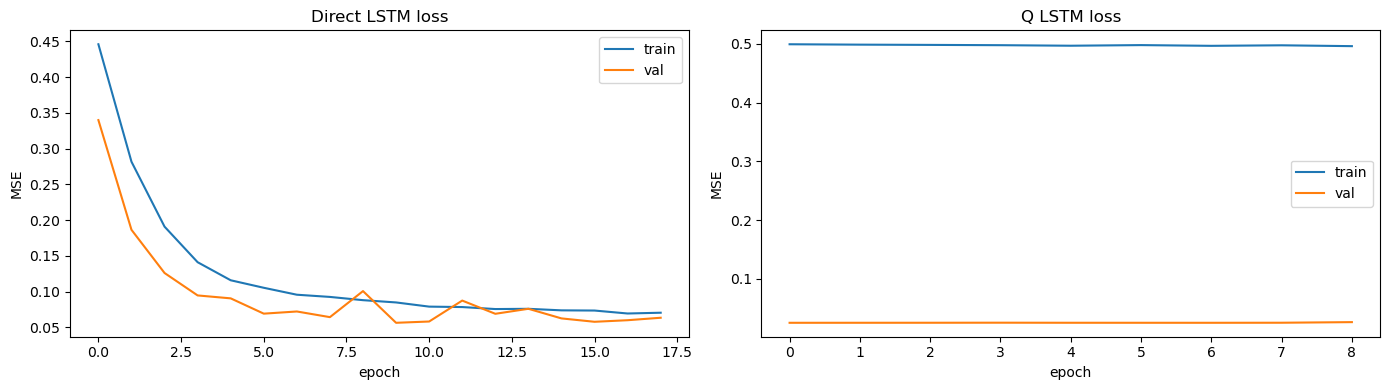

In [18]:
# -----------------------------
# Optional: inspect training curves
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hist_C["train_loss"], label="train")
ax[0].plot(hist_C["val_loss"], label="val")
ax[0].set_title("Direct LSTM loss")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("MSE")
ax[0].legend()

ax[1].plot(hist_Q["train_loss"], label="train")
ax[1].plot(hist_Q["val_loss"], label="val")
ax[1].set_title("Q LSTM loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("MSE")
ax[1].legend()

plt.tight_layout()
plt.show()

## Notes

- `Q` here is a **derived latent target**, generated using the inverse problem on each timestamp.
- The direct concentration model and the `Q` model are trained on the **same time split**, so the comparison is fair.
- If you want a stronger physics-informed experiment, the next step is to add the transport loss:
  `loss = MSE(Q_pred, Q_target) + λ * MSE(T @ Q_pred, C_true)`.